[2026-07-28 00:59:20] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-10-31 23:59:59
[2026-07-28 01:00:24] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-10-31 23:59:59
[2026-07-28 01:00:25] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-28 01:00:27] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-28 01:00:27] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-10-31
[2026-07-28 01:00:27] [info     ] ========== 数据检查 ==========
[2026-07-28 01:00:27] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_l

时段,IC
2024-01-15~2024-02-08,0.0024
2024-09-24~2024-10-08,-0.0280

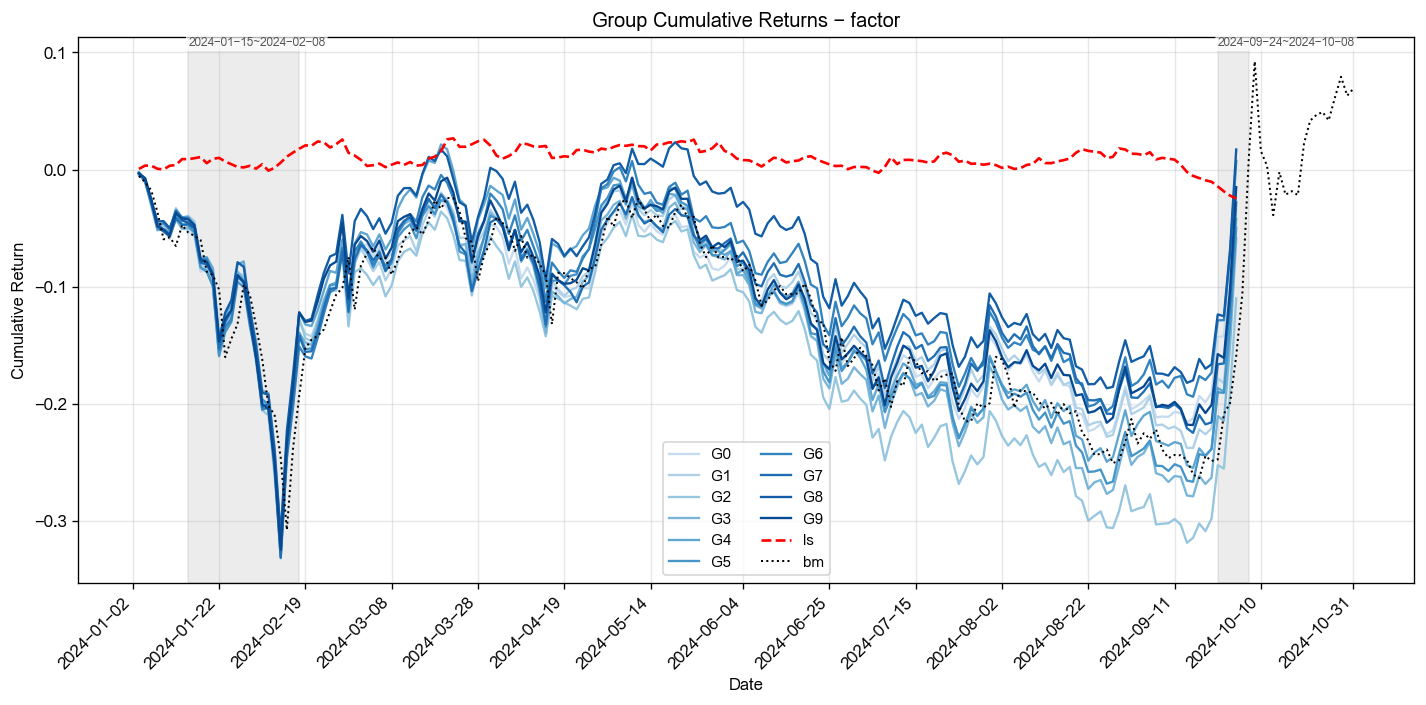
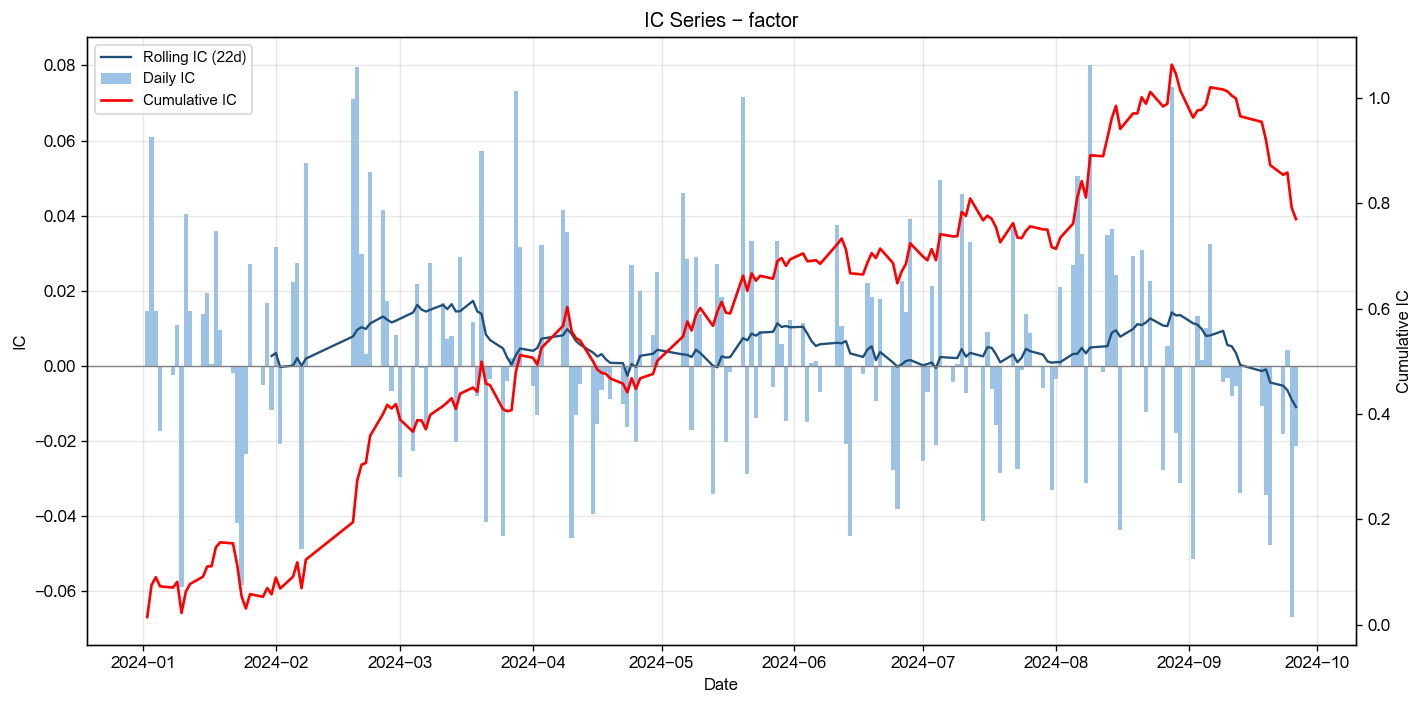
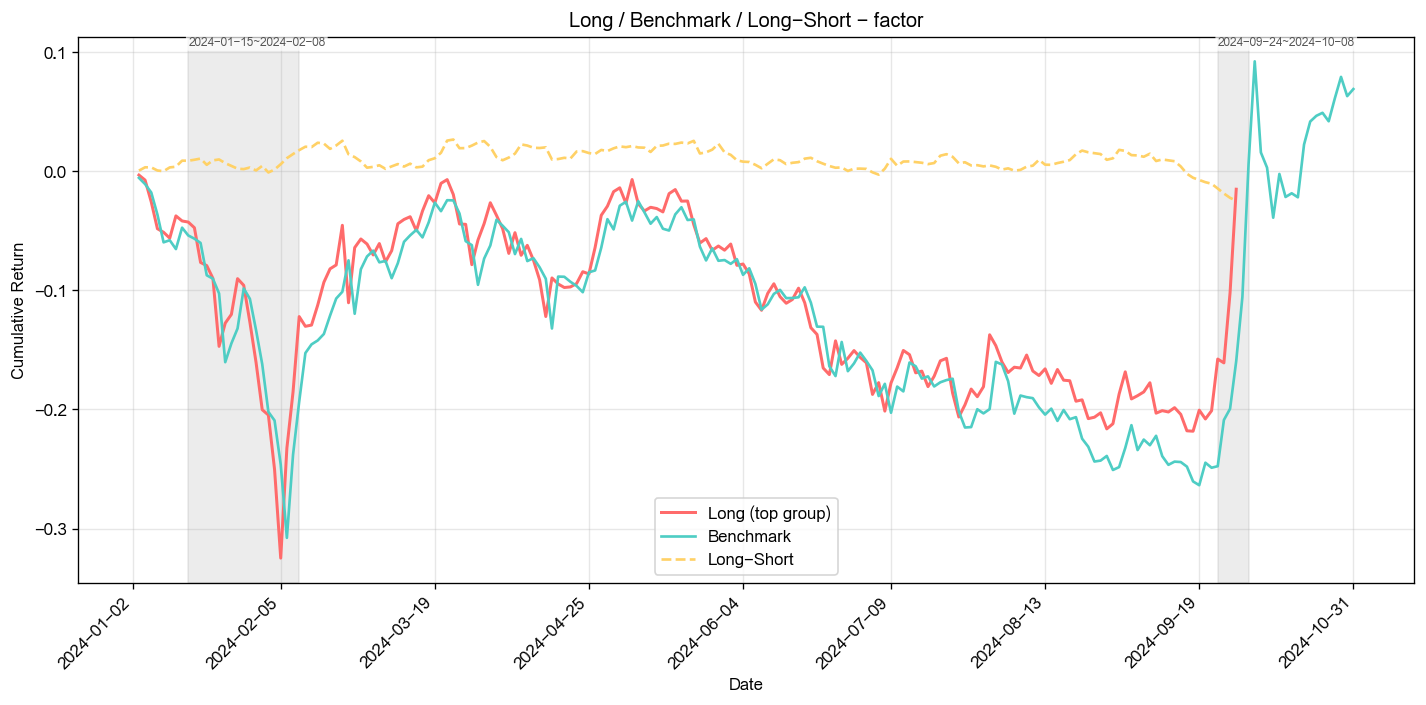
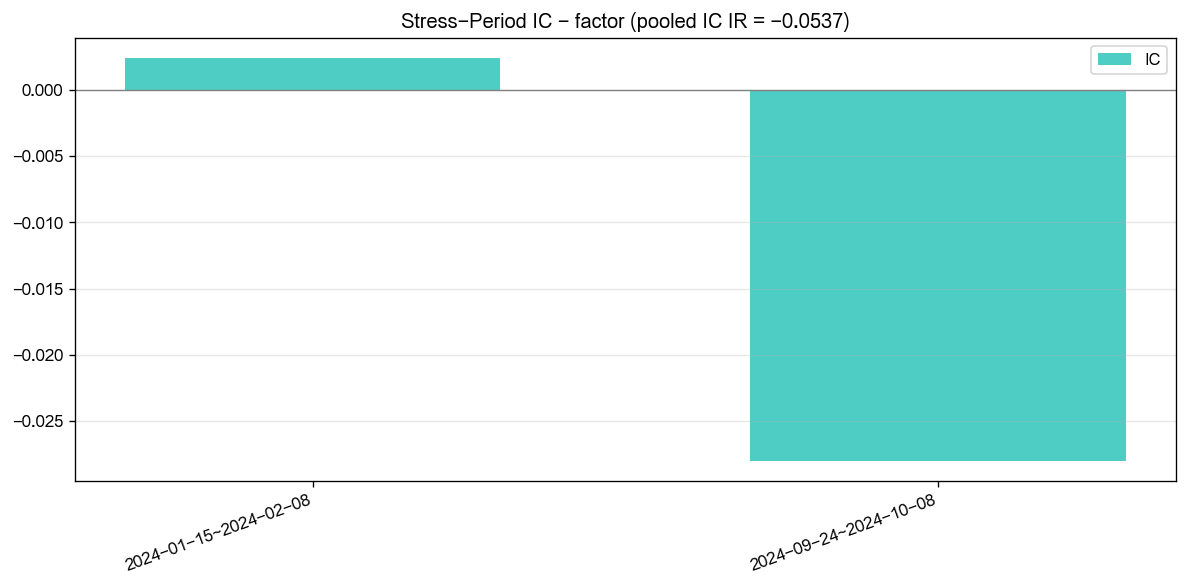
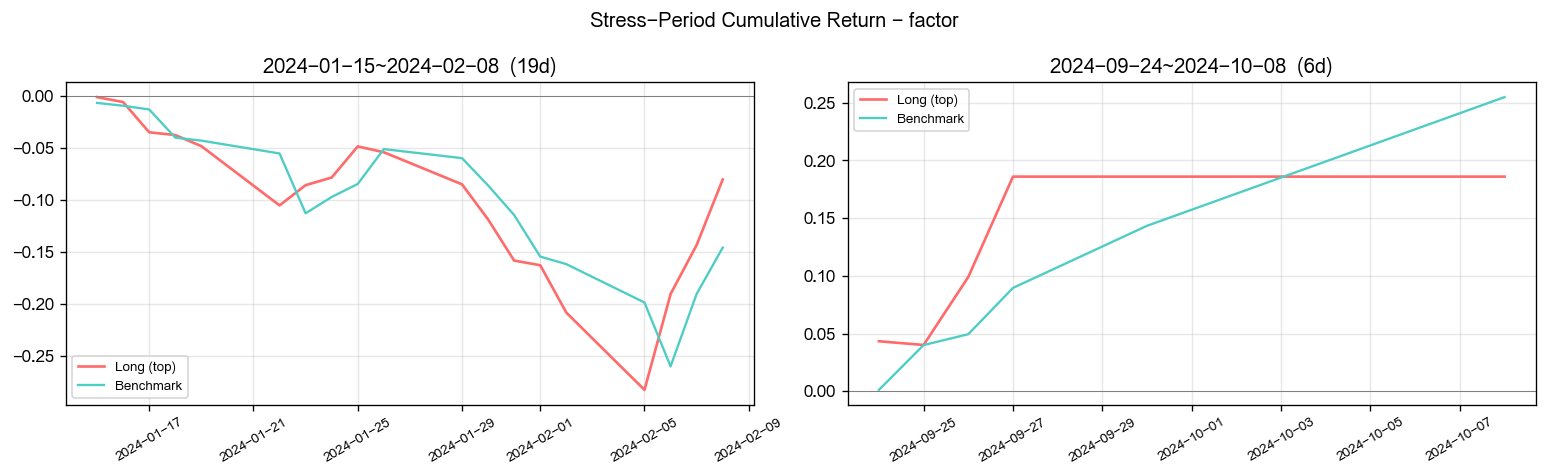

[2026-07-28 01:00:39] [info     ] ========== 因子池回归 ==========
[2026-07-28 01:00:39] [info     ] 加载 T+1 收益数据完成                  end_date=2024-10-31 instrument_count=1106 rows=228070 start_date=2024-01-02
[2026-07-28 01:00:39] [info     ] 获取收益率数据, 耗时: 0.608 秒
[2026-07-28 01:00:39] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.0792 秒
[2026-07-28 01:00:39] [info     ] 统计 回归结果, 耗时: 0.0153 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,kdj_d_9_3_3,2.6037,0.0152,0.0058,1.0000
2,netflow_amount_rate_main,2.1954,0.0065,0.0030,1.0000
3,gross_profit_rate_ttm,1.8307,0.0079,0.0043,1.0000
4,amount,1.8170,0.0203,0.0112,0.8571
5,volatility_5,1.8120,0.0230,0.0127,1.0000
6,roa_avg_ttm,1.6605,0.0157,0.0095,0.8571
7,rsi_12,1.5773,0.0395,0.0251,1.0000
8,net_profit_rate_ttm,1.5505,0.0045,0.0029,0.8571
9,macd_dea_12_26_9,1.5463,0.0063,0.0041,0.8571
10,pb,1.5341,0.0064,0.0042,1.0000

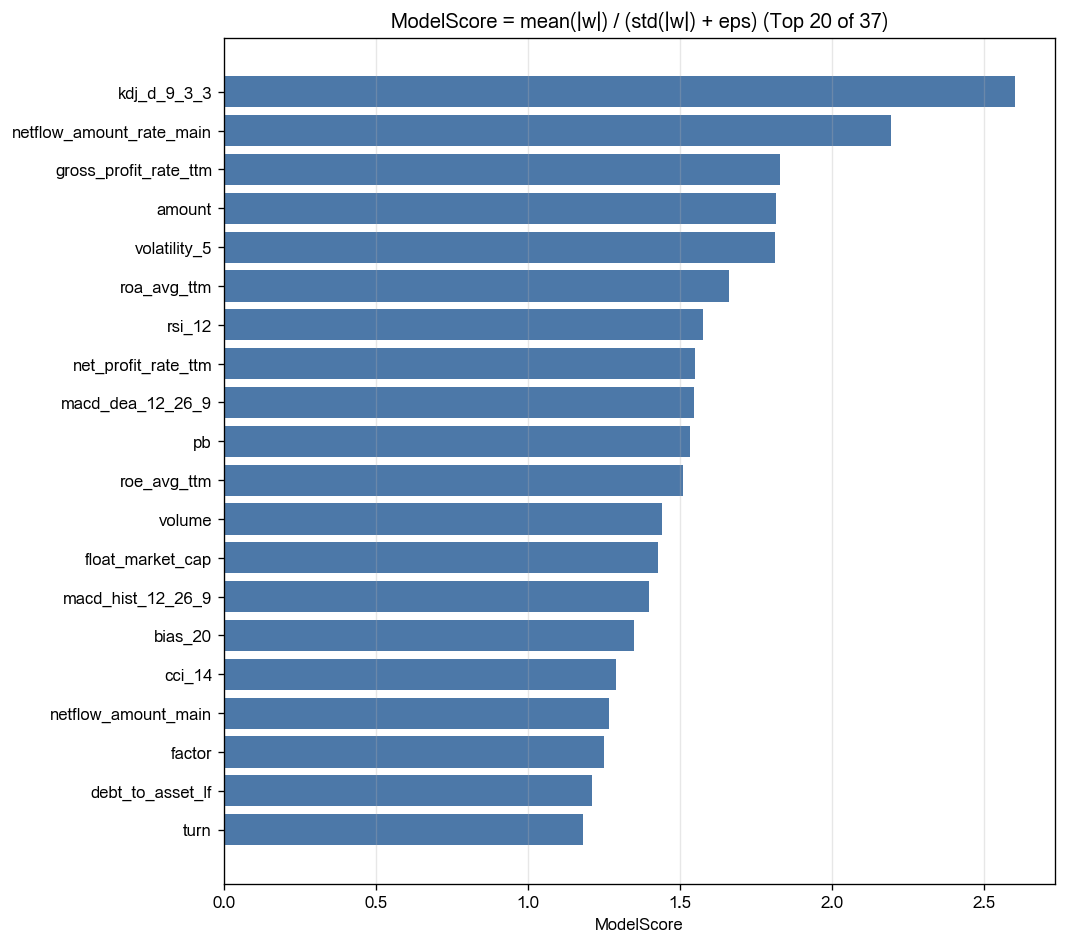
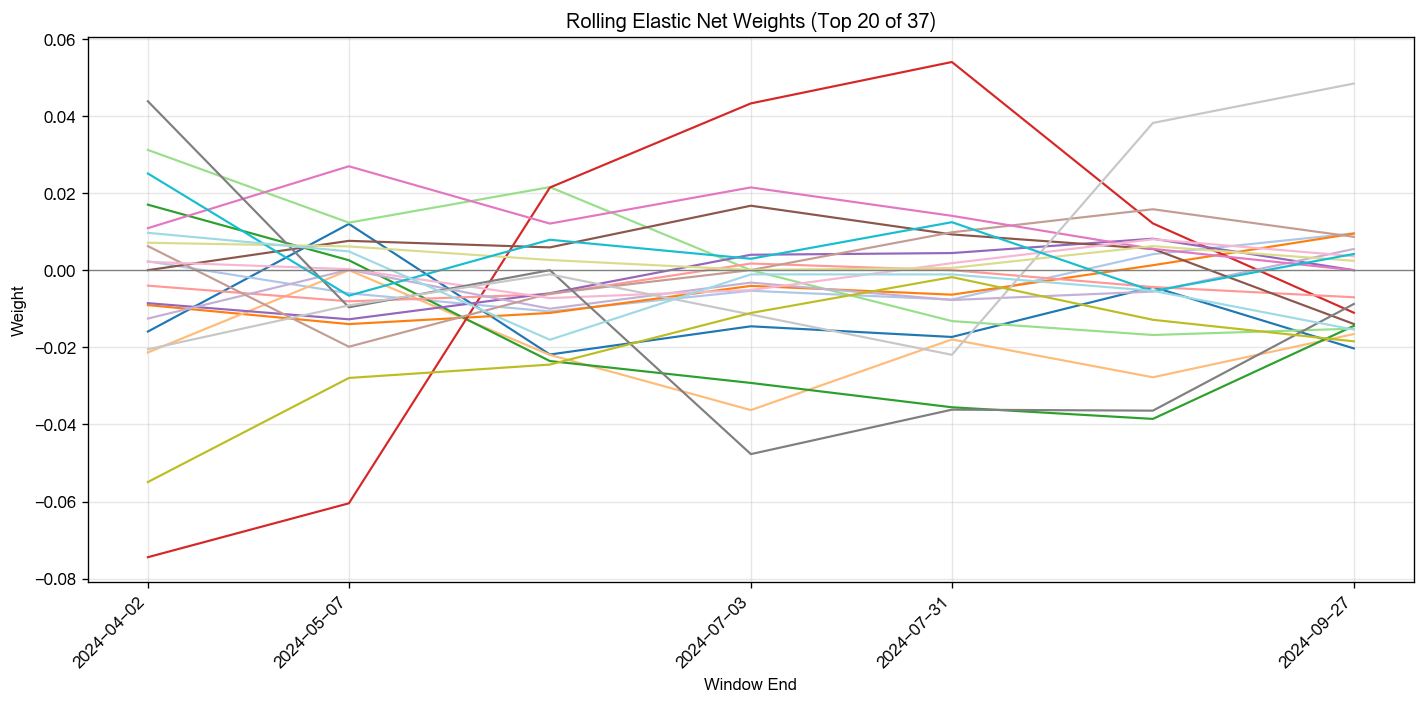
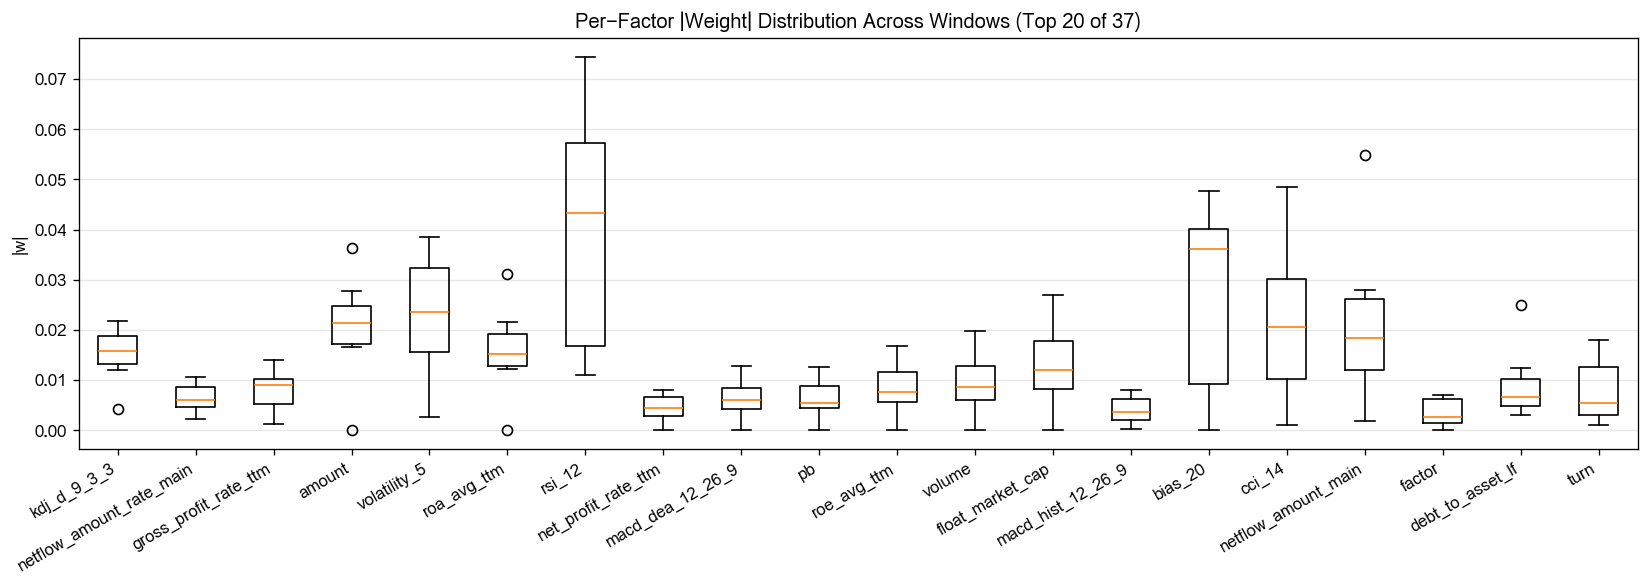
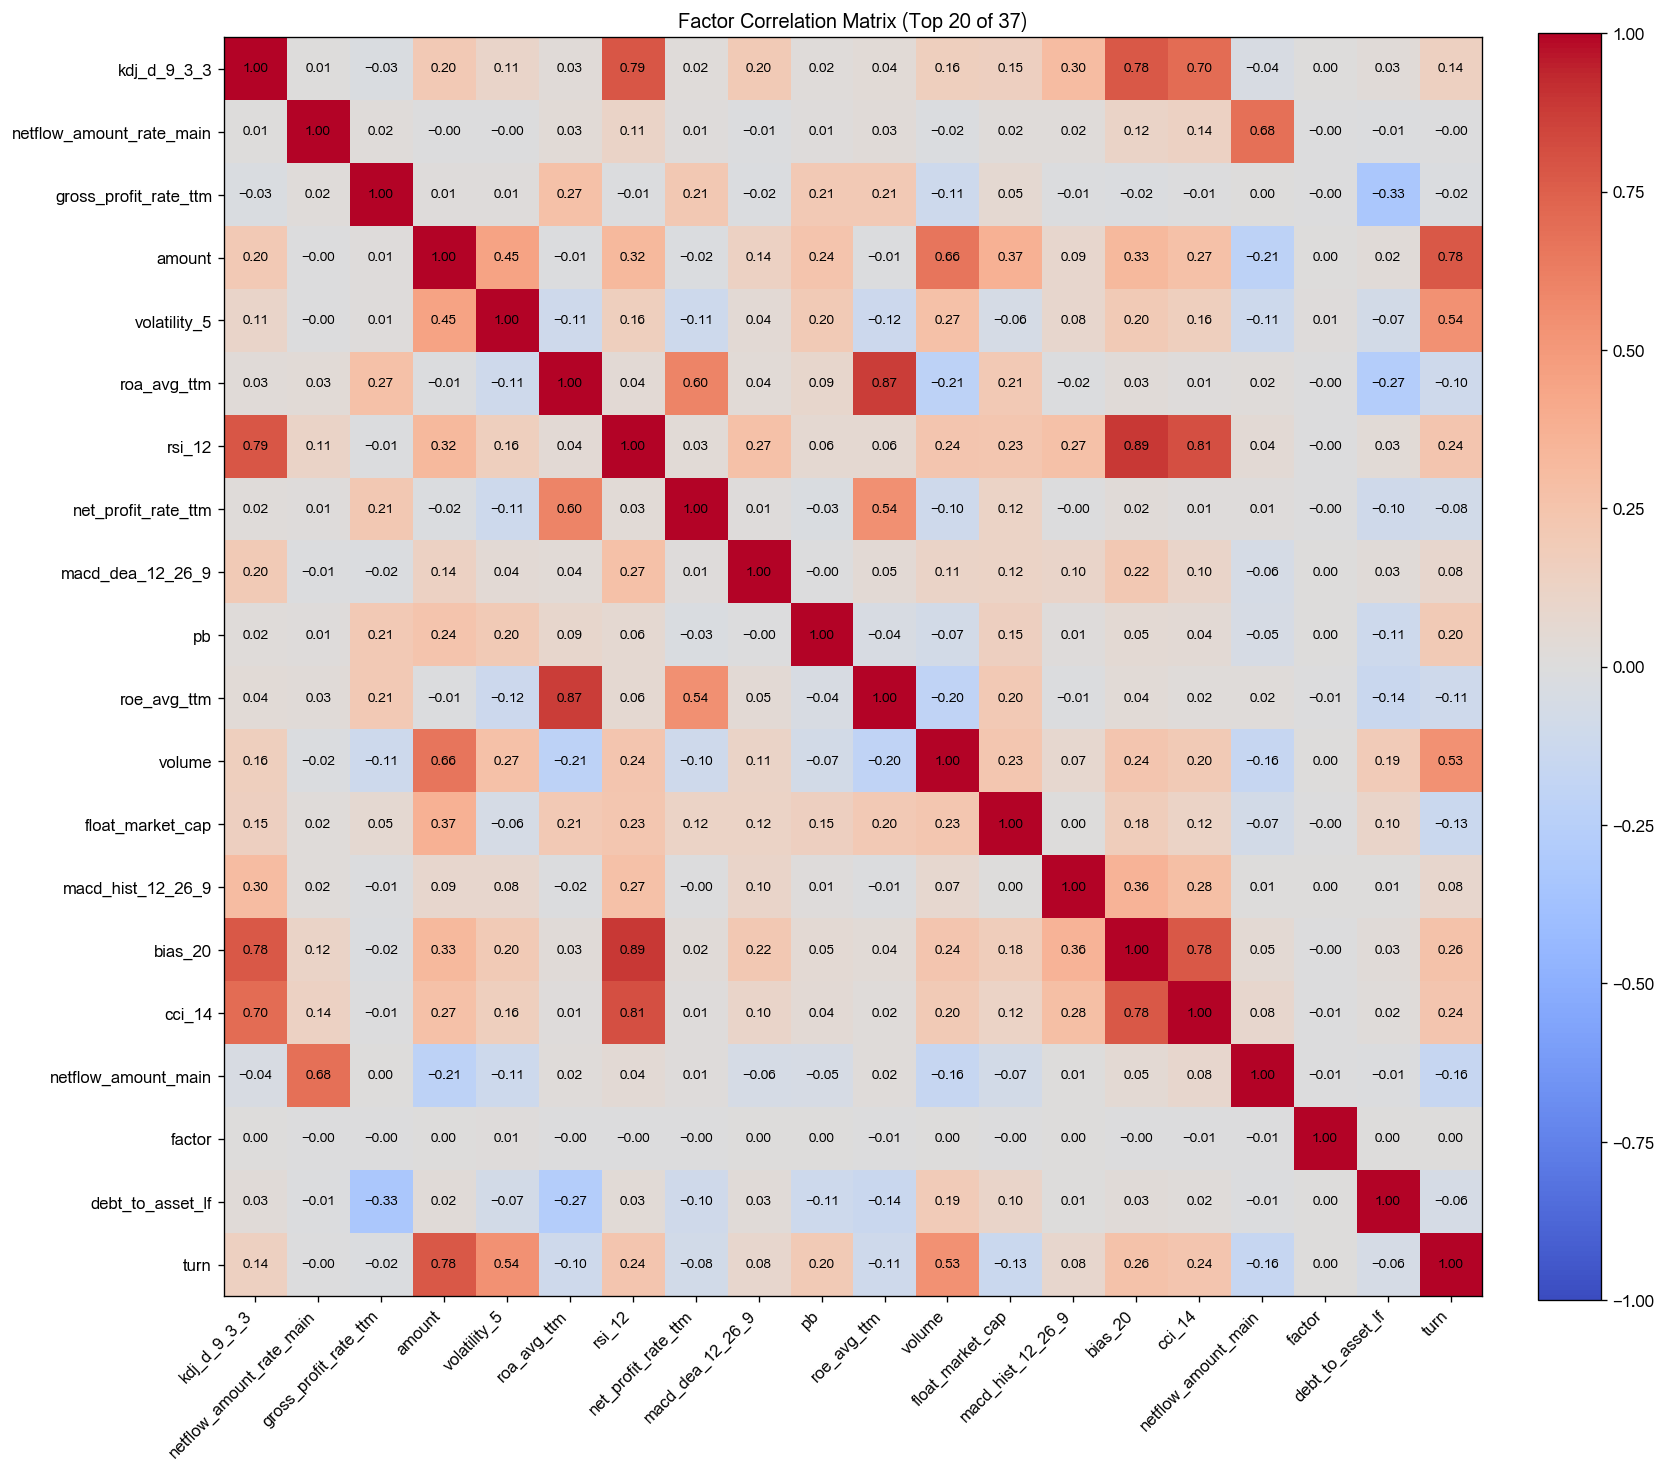

[2026-07-28 01:00:42] [warning  ] 返回的Outputs实例(size=27728620) 大于 64K, 将不会被缓存
[2026-07-28 01:00:42] [info     ] bigalpha_eval.v4 运行完成 [15.073s].


In [1]:
def main(datasources, start_date, end_date):
    """
    BigAlpha 2026 因子：
    尾盘负冲击修复加速因子
    Late-session Negative-shock Repair Acceleration

    factor 越大：
    尾盘负价格冲击的快速修复能力越强，
    且不能被普通反转、收益、波动、价差和成交额解释。
    """

    import numpy as np
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]

    eval_start = pd.Timestamp(start_date).normalize()
    eval_end = pd.Timestamp(end_date).normalize()

    # 三日平滑需要向前读取历史数据
    query_start = eval_start - pd.Timedelta(days=14)

    query_start_str = query_start.strftime("%Y-%m-%d 00:00:00")
    eval_start_str = eval_start.strftime("%Y-%m-%d 00:00:00")
    eval_end_str = eval_end.strftime("%Y-%m-%d 23:59:59")

    sql = f"""
    WITH base AS (
        SELECT
            date AS bar_time,
            date::DATE::DATETIME AS trading_date,
            instrument,
            close,
            amount,
            ask_price1,
            bid_price1,

            CASE
                WHEN (
                    (hour(date) = 9 AND minute(date) >= 31)
                    OR hour(date) = 10
                    OR (hour(date) = 11 AND minute(date) <= 30)
                    OR hour(date) = 13
                ) THEN 0

                WHEN (
                    hour(date) = 14
                    AND minute(date) <= 56
                ) THEN 1

                ELSE NULL
            END AS is_tail,

            LAG(close, 1) OVER (
                PARTITION BY instrument, date::DATE
                ORDER BY date
            ) AS prev_close

        FROM {bar1m}

        WHERE
            close > 0
            AND amount >= 0
            AND ask_price1 > 0
            AND bid_price1 > 0
            AND ask_price1 >= bid_price1

            -- 连续竞价时段，排除收盘集合竞价
            AND (
                (hour(date) = 9 AND minute(date) >= 31)
                OR hour(date) = 10
                OR (hour(date) = 11 AND minute(date) <= 30)
                OR hour(date) = 13
                OR (hour(date) = 14 AND minute(date) <= 56)
            )
    ),

    minute_return AS (
        SELECT
            bar_time,
            trading_date,
            instrument,
            close,
            amount,
            is_tail,

            close / NULLIF(prev_close, 0) - 1.0 AS ret_1m,

            (
                ask_price1 - bid_price1
            )
            /
            NULLIF(
                0.5 * (ask_price1 + bid_price1),
                0
            ) AS relative_spread

        FROM base

        WHERE
            prev_close > 0
            AND is_tail IS NOT NULL
    ),

    lagged_return AS (
        SELECT
            bar_time,
            trading_date,
            instrument,
            close,
            amount,
            is_tail,
            ret_1m,
            relative_spread,

            LAG(ret_1m, 1) OVER (
                PARTITION BY instrument, trading_date
                ORDER BY bar_time
            ) AS prev_ret_1m

        FROM minute_return
    ),

    minute_component AS (
        SELECT
            bar_time,
            trading_date,
            instrument,
            close,
            amount,
            is_tail,
            ret_1m,
            relative_spread,
            prev_ret_1m,

            -- 前一分钟下跌、当前分钟上涨
            CASE
                WHEN prev_ret_1m < 0
                     AND ret_1m > 0
                THEN (-prev_ret_1m) * ret_1m
                ELSE 0.0
            END AS negative_repair,

            -- 前一分钟上涨、当前分钟下跌
            CASE
                WHEN prev_ret_1m > 0
                     AND ret_1m < 0
                THEN prev_ret_1m * (-ret_1m)
                ELSE 0.0
            END AS positive_fade,

            CASE
                WHEN prev_ret_1m < 0
                THEN prev_ret_1m * prev_ret_1m
                ELSE 0.0
            END AS negative_shock_energy,

            CASE
                WHEN prev_ret_1m > 0
                THEN prev_ret_1m * prev_ret_1m
                ELSE 0.0
            END AS positive_shock_energy,

            CASE
                WHEN prev_ret_1m * ret_1m < 0
                THEN 1.0
                ELSE 0.0
            END AS sign_reversal

        FROM lagged_return

        WHERE
            prev_ret_1m IS NOT NULL
            AND ret_1m IS NOT NULL
            AND relative_spread IS NOT NULL
    ),

    session_stat AS (
        SELECT
            trading_date AS date,
            instrument,
            is_tail,

            COALESCE(
                SUM(negative_repair)
                /
                NULLIF(
                    SUM(negative_shock_energy),
                    0
                ),
                0.0
            ) AS negative_repair_ratio,

            COALESCE(
                SUM(positive_fade)
                /
                NULLIF(
                    SUM(positive_shock_energy),
                    0
                ),
                0.0
            ) AS positive_fade_ratio,

            AVG(sign_reversal) AS reversal_rate,

            FIRST(close ORDER BY bar_time)
                AS session_first_close,

            LAST(close ORDER BY bar_time)
                AS session_last_close,

            COUNT(*) AS session_obs

        FROM minute_component

        GROUP BY
            trading_date,
            instrument,
            is_tail
    ),

    day_stat AS (
        SELECT
            trading_date AS date,
            instrument,

            FIRST(close ORDER BY bar_time)
                AS day_first_close,

            LAST(close ORDER BY bar_time)
                AS day_last_close,

            SQRT(
                SUM(ret_1m * ret_1m)
            ) AS realized_vol,

            SUM(
                ABS(ret_1m)
            ) AS path_length,

            AVG(
                relative_spread
            ) AS mean_spread,

            LN(
                1.0
                +
                SUM(
                    CASE
                        WHEN amount > 0
                        THEN amount
                        ELSE 0
                    END
                )
            ) AS log_amount,

            COUNT(*) AS total_obs

        FROM minute_component

        GROUP BY
            trading_date,
            instrument
    ),

    combined AS (
        SELECT
            d.date,
            d.instrument,

            MAX(
                CASE
                    WHEN s.is_tail = 0
                    THEN s.negative_repair_ratio
                END
            ) AS early_negative_repair,

            MAX(
                CASE
                    WHEN s.is_tail = 0
                    THEN s.positive_fade_ratio
                END
            ) AS early_positive_fade,

            MAX(
                CASE
                    WHEN s.is_tail = 1
                    THEN s.negative_repair_ratio
                END
            ) AS tail_negative_repair,

            MAX(
                CASE
                    WHEN s.is_tail = 1
                    THEN s.positive_fade_ratio
                END
            ) AS tail_positive_fade,

            MAX(
                CASE
                    WHEN s.is_tail = 0
                    THEN s.reversal_rate
                END
            ) AS early_reversal_rate,

            MAX(
                CASE
                    WHEN s.is_tail = 1
                    THEN s.reversal_rate
                END
            ) AS tail_reversal_rate,

            MAX(
                CASE
                    WHEN s.is_tail = 1
                    THEN s.session_first_close
                END
            ) AS tail_first_close,

            MAX(
                CASE
                    WHEN s.is_tail = 1
                    THEN s.session_last_close
                END
            ) AS tail_last_close,

            MAX(
                CASE
                    WHEN s.is_tail = 0
                    THEN s.session_obs
                END
            ) AS early_obs,

            MAX(
                CASE
                    WHEN s.is_tail = 1
                    THEN s.session_obs
                END
            ) AS tail_obs,

            d.day_first_close,
            d.day_last_close,
            d.realized_vol,
            d.path_length,
            d.mean_spread,
            d.log_amount,
            d.total_obs

        FROM day_stat d

        LEFT JOIN session_stat s
            ON d.date = s.date
            AND d.instrument = s.instrument

        GROUP BY
            d.date,
            d.instrument,
            d.day_first_close,
            d.day_last_close,
            d.realized_vol,
            d.path_length,
            d.mean_spread,
            d.log_amount,
            d.total_obs
    )

    SELECT
        date,
        instrument,

        early_negative_repair,
        early_positive_fade,
        tail_negative_repair,
        tail_positive_fade,

        early_reversal_rate,
        tail_reversal_rate,

        tail_first_close,
        tail_last_close,
        day_first_close,
        day_last_close,

        realized_vol,
        path_length,
        mean_spread,
        log_amount,

        total_obs,
        early_obs,
        tail_obs

    FROM combined

    WHERE
        early_obs >= 70
        AND tail_obs >= 25
        AND total_obs >= 100

        AND day_first_close > 0
        AND day_last_close > 0
        AND tail_first_close > 0
        AND tail_last_close > 0

    ORDER BY
        date,
        instrument
    """

    feature = dai.query(
        sql,
        filters={
            "date": [
                query_start_str,
                eval_end_str,
            ]
        },
        compression=True,
    ).df()

    # 读取历史时点上的中证1000股票池
    pool = dai.query(
        """
        SELECT
            date::DATE::DATETIME AS date,
            instrument
        FROM bigalpha_2026_instruments
        ORDER BY date, instrument
        """,
        filters={
            "date": [
                eval_start_str,
                eval_end_str,
            ]
        },
        compression=True,
    ).df()

    pool["date"] = (
        pd.to_datetime(pool["date"])
        .dt.normalize()
    )

    pool["instrument"] = (
        pool["instrument"]
        .astype(str)
    )

    pool = pool.drop_duplicates(
        ["date", "instrument"]
    )

    if feature.empty:
        pool["factor"] = 0.0

        return (
            pool[
                ["date", "instrument", "factor"]
            ]
            .sort_values(
                ["date", "instrument"]
            )
            .reset_index(drop=True)
        )

    feature["date"] = (
        pd.to_datetime(feature["date"])
        .dt.normalize()
    )

    feature["instrument"] = (
        feature["instrument"]
        .astype(str)
    )

    feature = feature.drop_duplicates(
        ["date", "instrument"]
    )

    numeric_cols = [
        "early_negative_repair",
        "early_positive_fade",
        "tail_negative_repair",
        "tail_positive_fade",
        "early_reversal_rate",
        "tail_reversal_rate",
        "tail_first_close",
        "tail_last_close",
        "day_first_close",
        "day_last_close",
        "realized_vol",
        "path_length",
        "mean_spread",
        "log_amount",
    ]

    for col in numeric_cols:
        feature[col] = pd.to_numeric(
            feature[col],
            errors="coerce",
        )

    # 早盘和尾盘的价格修复韧性
    feature["early_resilience"] = (
        feature["early_negative_repair"]
        - feature["early_positive_fade"]
    ).clip(-3.0, 3.0)

    feature["tail_resilience"] = (
        feature["tail_negative_repair"]
        - feature["tail_positive_fade"]
    ).clip(-3.0, 3.0)

    # 核心原始因子
    feature["resilience_accel"] = (
        feature["tail_resilience"]
        - feature["early_resilience"]
    )

    # 普通正负收益交替频率，作为控制变量
    feature["reversal_accel"] = (
        feature["tail_reversal_rate"]
        - feature["early_reversal_rate"]
    )

    feature["tail_return"] = (
        feature["tail_last_close"]
        /
        feature["tail_first_close"].replace(
            0.0,
            np.nan,
        )
        - 1.0
    )

    feature["daily_return"] = (
        feature["day_last_close"]
        /
        feature["day_first_close"].replace(
            0.0,
            np.nan,
        )
        - 1.0
    )

    # 路径长度相对净收益越高，日内价格越曲折
    feature["noise_ratio"] = (
        feature["path_length"]
        /
        (
            feature["daily_return"].abs()
            + 1e-4
        )
    ).clip(0.0, 100.0)

    feature = feature.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    feature = (
        feature
        .sort_values(
            ["instrument", "date"]
        )
        .reset_index(drop=True)
    )

    # 三日过去向平滑
    smooth_cols = [
        "resilience_accel",
        "reversal_accel",
        "tail_return",
        "daily_return",
        "realized_vol",
        "noise_ratio",
        "mean_spread",
        "log_amount",
    ]

    for col in smooth_cols:
        feature[f"{col}_3d"] = (
            feature
            .groupby(
                "instrument",
                sort=False,
            )[col]
            .transform(
                lambda s: s.rolling(
                    window=3,
                    min_periods=2,
                ).mean()
            )
        )

    feature["factor"] = np.nan

    control_cols = [
        "reversal_accel_3d",
        "tail_return_3d",
        "daily_return_3d",
        "realized_vol_3d",
        "noise_ratio_3d",
        "mean_spread_3d",
        "log_amount_3d",
    ]

    # 每日截面残差化
    for _, index in feature.groupby(
        "date",
        sort=False,
    ).groups.items():

        index = list(index)
        day = feature.loc[index]

        y = (
            day["resilience_accel_3d"]
            .rank(
                method="average",
                pct=True,
            )
            - 0.5
        )

        x_frame = pd.concat(
            [
                day[col]
                .rank(
                    method="average",
                    pct=True,
                )
                - 0.5
                for col in control_cols
            ],
            axis=1,
        )

        valid = (
            y.notna()
            & x_frame.notna().all(axis=1)
        )

        residual = pd.Series(
            np.nan,
            index=day.index,
            dtype=float,
        )

        if int(valid.sum()) >= 50:
            X = x_frame.loc[
                valid
            ].to_numpy(dtype=float)

            Y = y.loc[
                valid
            ].to_numpy(dtype=float)

            # 微小岭正则，避免控制变量共线
            ridge = (
                1e-5
                * np.eye(X.shape[1])
            )

            beta = np.linalg.solve(
                X.T @ X + ridge,
                X.T @ Y,
            )

            beta = np.clip(
                beta,
                -3.0,
                3.0,
            )

            residual.loc[valid] = (
                Y - X @ beta
            )

            # 最终转为每日截面百分位
            residual.loc[valid] = (
                residual.loc[valid]
                .rank(
                    method="average",
                    pct=True,
                )
                - 0.5
            )

        else:
            residual.loc[valid] = 0.0

        feature.loc[
            residual.index,
            "factor",
        ] = residual

    # 裁剪回正式评估区间
    factor = feature.loc[
        (
            feature["date"]
            >= eval_start
        )
        &
        (
            feature["date"]
            <= eval_end
        ),
        [
            "date",
            "instrument",
            "factor",
        ],
    ].copy()

    # 与历史股票池对齐
    result = pool.merge(
        factor,
        on=[
            "date",
            "instrument",
        ],
        how="left",
        validate="one_to_one",
    )

    # 停牌或分钟数据不足时，赋予截面中性值
    result["factor"] = (
        pd.to_numeric(
            result["factor"],
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(0.0)
        .astype(float)
    )

    # 必须且只能返回三列
    return (
        result[
            [
                "date",
                "instrument",
                "factor",
            ]
        ]
        .sort_values(
            ["date", "instrument"]
        )
        .reset_index(drop=True)
    )


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m_selftest'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-10-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        start_date=start_date,
        end_date=end_date,
        process_pools=False,
        show=True,
    )